In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("books_data.csv")
df.head()

,Title,Price,Rating,Availability,URL
0,A Light in the Attic,Â£51.77,Three,In stock,catalogue/a-light-in-the-attic_1000/index.html
1,Tipping the Velvet,Â£53.74,One,In stock,catalogue/tipping-the-velvet_999/index.html
2,Soumission,Â£50.10,One,In stock,catalogue/soumission_998/index.html
3,Sharp Objects,Â£47.82,Four,In stock,catalogue/sharp-objects_997/index.html
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock,catalogue/sapiens-a-brief-history-of-humankind...


checking the price column

In [3]:
df["Price"] = (
    df["Price"]
    .str.replace("Â", "", regex=False)
    .str.replace("£", "", regex=False)
    .str.strip()
    .astype(float)
)

df["Price"].head()

0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: Price, dtype: float64

Rating Distribution

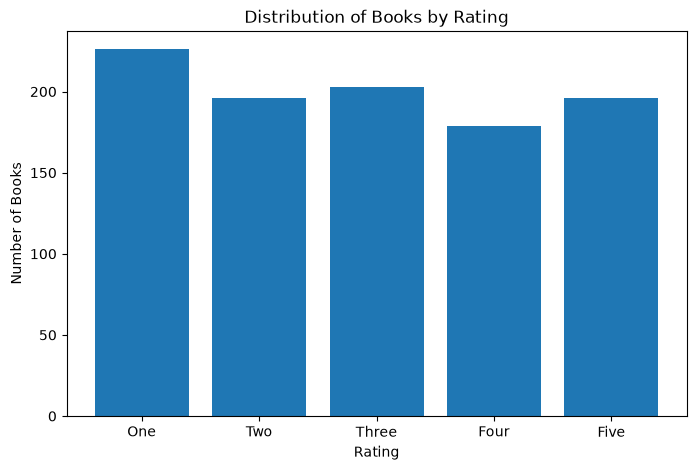

In [4]:
rating_counts = df["Rating"].value_counts()

rating_counts = rating_counts.reindex(
    ["One", "Two", "Three", "Four", "Five"]
)

plt.figure(figsize=(8, 5))

plt.bar(rating_counts.index, rating_counts.values)

plt.title("Distribution of Books by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.show()

### Interpretation

This bar chart shows the number of books in each rating category.
It helps identify which rating category is most common and how the
books are distributed across different ratings.

In [ ]:
Price visualization

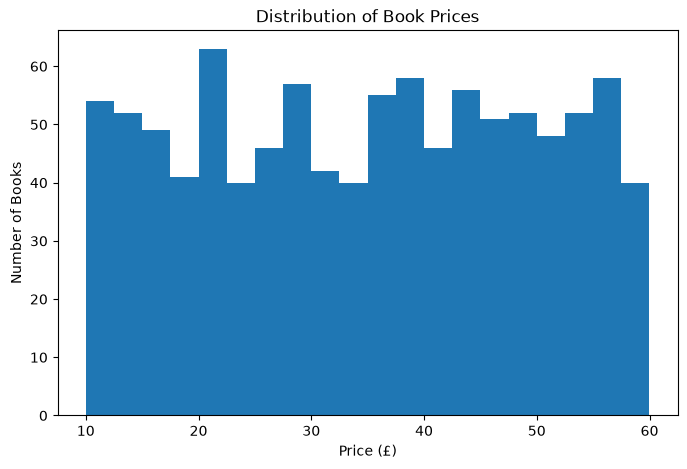

In [5]:
plt.figure(figsize=(8, 5))

plt.hist(df["Price"], bins=20)

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.show()

### Interpretation

The histogram shows the distribution of book prices across different
price ranges. It helps identify the price range in which most books
are concentrated and whether the distribution contains unusually
high or low values.

Average Price by rating

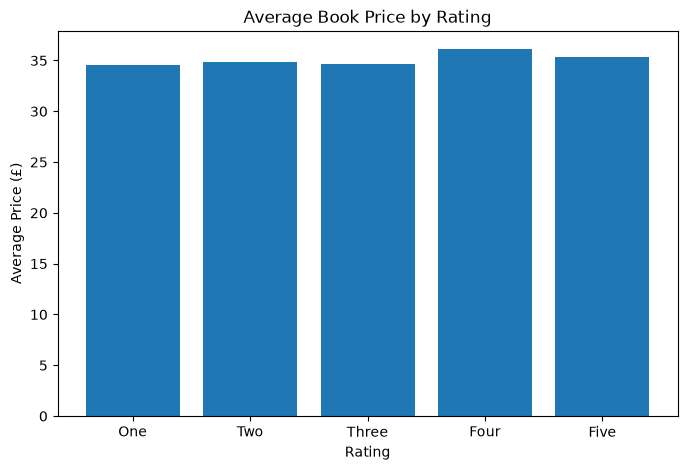

In [6]:
rating_order = ["One", "Two", "Three", "Four", "Five"]

avg_price_rating = (
    df.groupby("Rating")["Price"]
    .mean()
    .reindex(rating_order)
)

plt.figure(figsize=(8, 5))

plt.bar(
    avg_price_rating.index,
    avg_price_rating.values
)

plt.title("Average Book Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price (£)")

plt.show()

### Interpretation

This chart compares the average price of books across different
rating categories. It helps determine whether higher-rated books
tend to have higher or lower average prices.

Top 10 Most Expensive Books

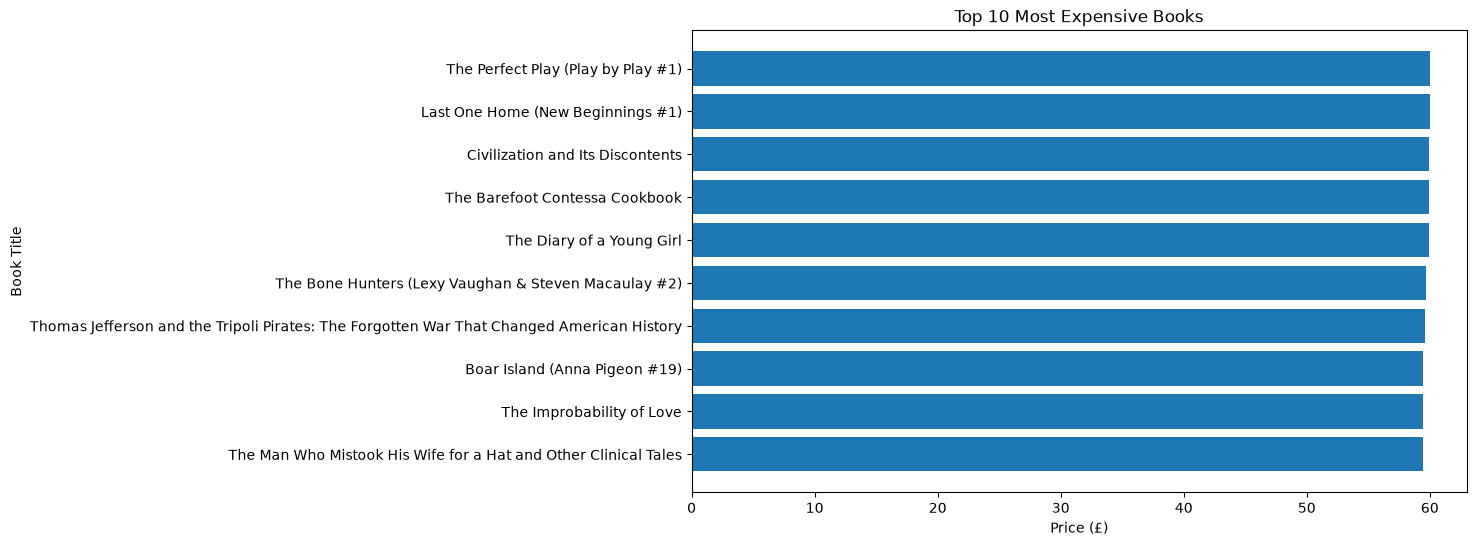

In [7]:
top_10 = df.nlargest(10, "Price")

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Title"],
    top_10["Price"]
)

plt.title("Top 10 Most Expensive Books")
plt.xlabel("Price (£)")
plt.ylabel("Book Title")

plt.gca().invert_yaxis()

plt.show()

### Interpretation

This chart presents the 10 most expensive books in the dataset.
It allows the highest-priced books to be quickly compared with
each other.

Price vs Rating

In [8]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating_Numeric"] = df["Rating"].map(rating_map)

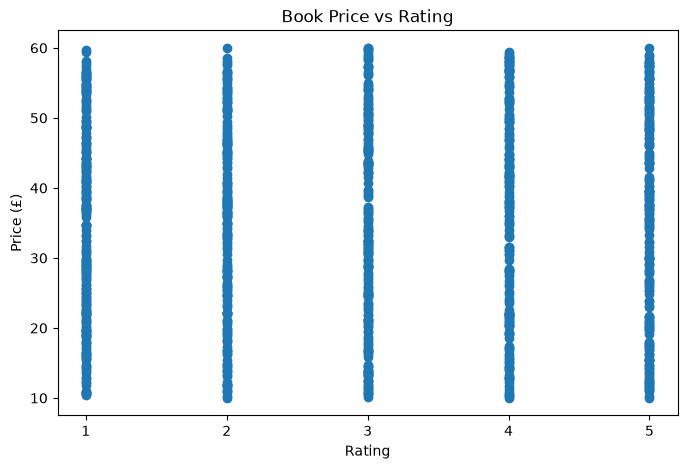

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Rating_Numeric"],
    df["Price"]
)

plt.title("Book Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.xticks([1, 2, 3, 4, 5])

plt.show()

### Interpretation

The scatter plot shows the relationship between book ratings and prices.

Book prices are widely distributed across all five rating categories, with
most rating groups containing books across a similar price range of
approximately £10 to £60.

There is no clear upward or downward pattern between rating and price.
This indicates that higher-rated books are not necessarily more expensive
than lower-rated books.

This observation is consistent with the calculated correlation value of
approximately 0.028, which indicates a very weak linear relationship between
book price and rating.

price distribution vs rating

<Figure size 800x500 with 0 Axes>

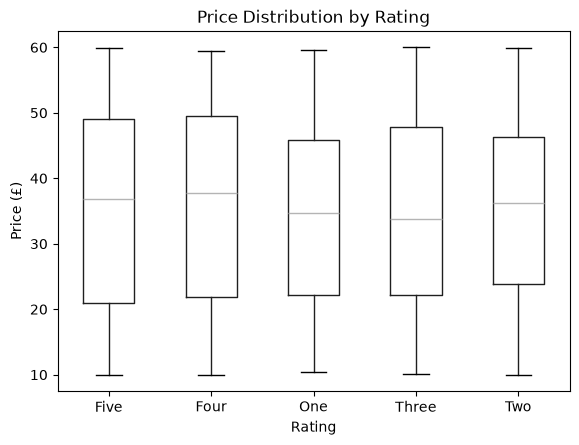

In [10]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="Price",
    by="Rating",
    grid=False
)

plt.title("Price Distribution by Rating")
plt.suptitle("")
plt.xlabel("Rating")
plt.ylabel("Price (£)")

plt.show()

### Interpretation

The box plot compares the distribution and spread of book prices
across rating categories. It provides a visual comparison of the
median prices and variation within each rating group.

# Visualization Summary

The visualizations provide different perspectives on the books dataset.

- The rating distribution shows how books are distributed across rating categories.
- The price histogram shows the overall distribution of book prices.
- Average price by rating allows comparison of pricing across rating groups.
- The top-10 chart identifies the most expensive books.
- The scatter plot visualizes the relationship between rating and price.
- The box plot compares price distributions across different rating categories.

Overall, the visualizations support the EDA findings and make the patterns
in the dataset easier to interpret.